# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [3]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [4]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [5]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 4. Load the Data


In [7]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    X_train_path = os.path.join(root_dir, "train", "X_train.txt")
    y_train_path = os.path.join(root_dir, "train", "y_train.txt")
    X_test_path  = os.path.join(root_dir, "test",  "X_test.txt")
    y_test_path  = os.path.join(root_dir, "test",  "y_test.txt")
    # Load data
    X_train = np.loadtxt(X_train_path)
    y_train = np.loadtxt(y_train_path).astype(int)

    X_test = np.loadtxt(X_test_path)
    y_test = np.loadtxt(y_test_path).astype(int)
    # 5. Convert the labels to zero-based class indices by subtracting 1
    y_train -= 1
    y_test  -= 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)

## 5. Quick Inspection


In [9]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
import numpy as np

# chat helped with the formatting here btw i could not make this 
print("Class Index | Class Name           | Count")
print("---------------------------------------------")

for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"{i:<11} | {name:<20} | {count}")

Class Index | Class Name           | Count
---------------------------------------------
0           | WALKING              | 1226
1           | WALKING_UPSTAIRS     | 1073
2           | WALKING_DOWNSTAIRS   | 986
3           | SITTING              | 1286
4           | STANDING             | 1374
5           | LAYING               | 1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [10]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-04-23 21:10:24.454841: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-23 21:10:24.458353: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Train the Baseline Model


In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks


# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
81/92 [=========================>....] - ETA: 0s - loss: 0.5271 - accuracy: 0.7926WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x7a0894687380> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the 

### Training Curves


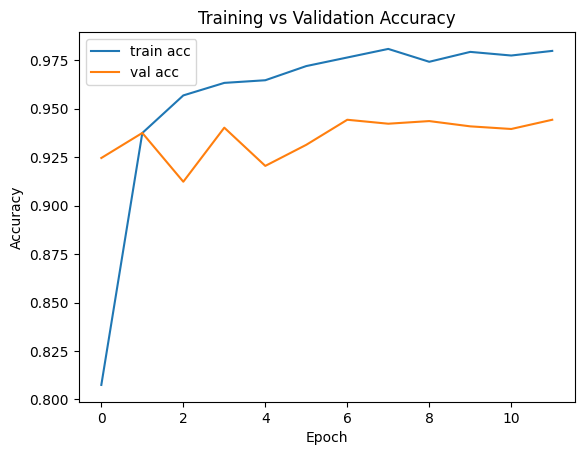

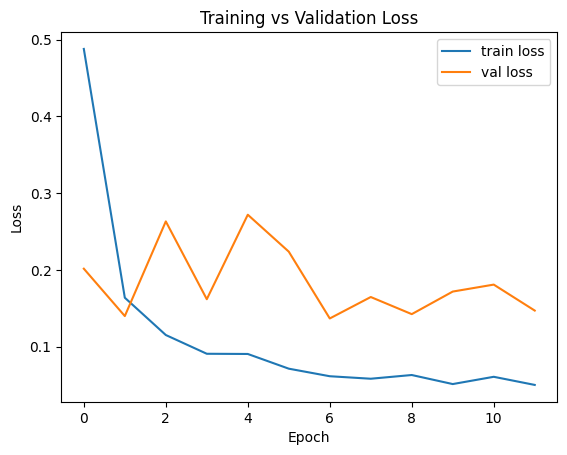

In [13]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

# chatgpt helped with the plotting as well (I am lazy too many plt)
plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## 7. Evaluate the Baseline Keras Model


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
93/93 [==============================] - 0s 908us/step
Test Accuracy: 0.9243298269426535

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.90      0.99      0.95       496
  WALKING_UPSTAIRS       0.88      0.93      0.91       471
WALKING_DOWNSTAIRS  

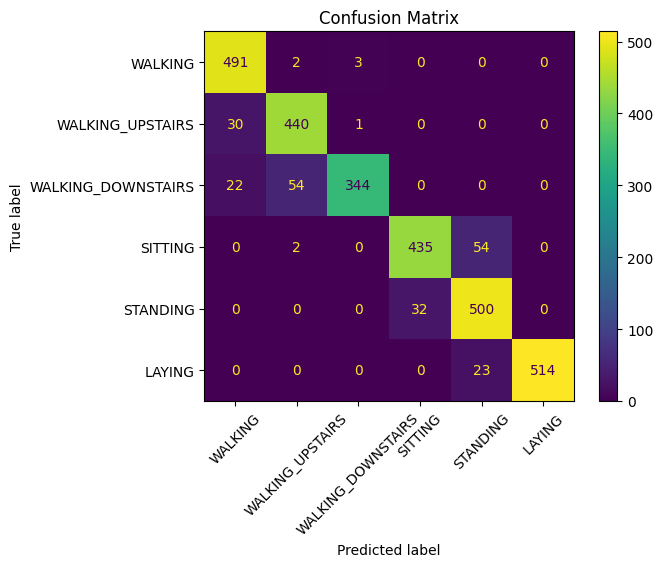

In [15]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

# predicted prob
y_probs = baseline_model.predict(X_test)

# convert prob
y_pred = np.argmax(y_probs, axis=1)

# test acc
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix")
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [16]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        sample = X_train[i].astype(np.float32)
        yield [sample.reshape(1, -1)] # ayo what gpt turned my for loop return to this because it wasnt really helping but this is cool

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = x / input_scale + input_zero_point
            x = np.round(x).astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#\
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale # I haven't really used this np.float32 thing but seems to help a lot - chatgpt rec + saw it used up there

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]

    return converter.convert() # cool

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen

    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    return converter.convert() # chat helped with this one


## 9. Post-Training Quantization (PTQ)


In [19]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
results = {}

# FP32 TFLite
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
results["FP32"] = (size_fp32, acc_fp32)

# dynamic range TFLite
tflite_dr = convert_to_tflite_dynamic_range(baseline_model)
size_dr = save_binary_model(tflite_dr, "model_dynamic.tflite")
acc_dr, _ = evaluate_tflite_model(tflite_dr, X_test, y_test)
results["Dynamic Range"] = (size_dr, acc_dr)

# float16 TFLite
tflite_f16 = convert_to_tflite_float16(baseline_model)
size_f16 = save_binary_model(tflite_f16, "model_float16.tflite")
acc_f16, _ = evaluate_tflite_model(tflite_f16, X_test, y_test)
results["Float16"] = (size_f16, acc_f16)

# int8 TFLite
tflite_int8 = convert_to_tflite_int8(baseline_model)
size_int8 = save_binary_model(tflite_int8, "model_int8.tflite")
acc_int8, _ = evaluate_tflite_model(tflite_int8, X_test, y_test)
results["INT8"] = (size_int8, acc_int8)

# Print results
print("Model Type | Size (KB) | Accuracy")
print("-----------------------------------")
for k, (size, acc) in results.items():
    print(f"{k:<13} | {size:<9.2f} | {acc:.4f}")

# chatgpt assisted with some minor code edits and table formatting

INFO:tensorflow:Assets written to: /tmp/tmpsxov9gbp/assets


INFO:tensorflow:Assets written to: /tmp/tmpsxov9gbp/assets
2026-04-23 21:34:02.862618: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:34:02.862664: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:34:02.862909: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsxov9gbp
2026-04-23 21:34:02.863603: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:34:02.863615: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpsxov9gbp
2026-04-23 21:34:02.866667: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:34:02.900921: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpsxov9gbp
2026-04-23 21:34:02.908601: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpcxdqq6q0/assets


INFO:tensorflow:Assets written to: /tmp/tmpcxdqq6q0/assets
2026-04-23 21:34:03.461577: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:34:03.461629: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:34:03.461776: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpcxdqq6q0
2026-04-23 21:34:03.462743: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:34:03.462763: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpcxdqq6q0
2026-04-23 21:34:03.466601: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:34:03.498106: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpcxdqq6q0
2026-04-23 21:34:03.505748: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpf5cmj3cx/assets


INFO:tensorflow:Assets written to: /tmp/tmpf5cmj3cx/assets
2026-04-23 21:34:04.039112: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:34:04.039169: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:34:04.039309: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpf5cmj3cx
2026-04-23 21:34:04.040164: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:34:04.040180: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpf5cmj3cx
2026-04-23 21:34:04.043530: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:34:04.084743: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpf5cmj3cx
2026-04-23 21:34:04.092619: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpk6z6v64r/assets


INFO:tensorflow:Assets written to: /tmp/tmpk6z6v64r/assets


Model Type | Size (KB) | Accuracy
-----------------------------------
FP32          | 726.72    | 0.9243
Dynamic Range | 186.11    | 0.9243
Float16       | 365.71    | 0.9243
INT8          | 185.34    | 0.9237


/home/thomas/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  input_array.mean_value, input_array.std_value = quantized_input_stats[
2026-04-23 21:34:04.986011: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:34:04.986064: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:34:04.986211: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpk6z6v64r
2026-04-23 21:34:04.987258: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:34:04.987271: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpk6z6v64r
2026-04-23 21:34:04.989272: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-

## 10. PTQ Comparison: Accuracy and Model Size


In [20]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

rows = []

for fmt, (size, acc) in results.items():
    rows.append({
        "Model Family": "Baseline DNN",
        "Format": fmt,
        "Test Accuracy": acc,
        "Model Size (KB)": size
    })

df = pd.DataFrame(rows)
df

#gpt told me to use pandas instead of doing whatever i was tryna do that wasnt working. reminded me of syntax

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,FP32,0.924330,726.718750
1,Baseline DNN,Dynamic Range,0.924330,186.109375
2,Baseline DNN,Float16,0.924330,365.710938
3,Baseline DNN,INT8,0.923651,185.335938


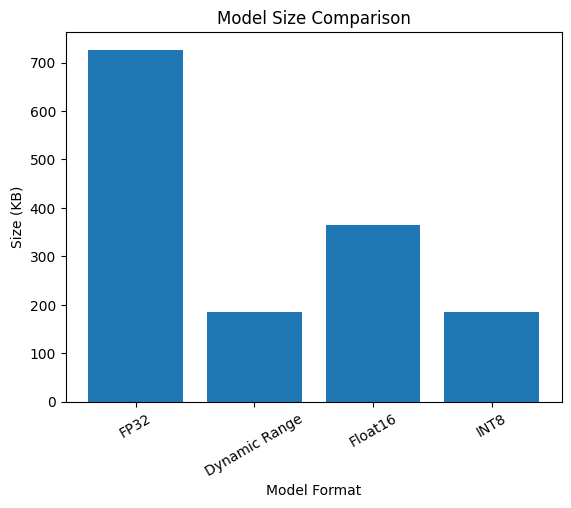

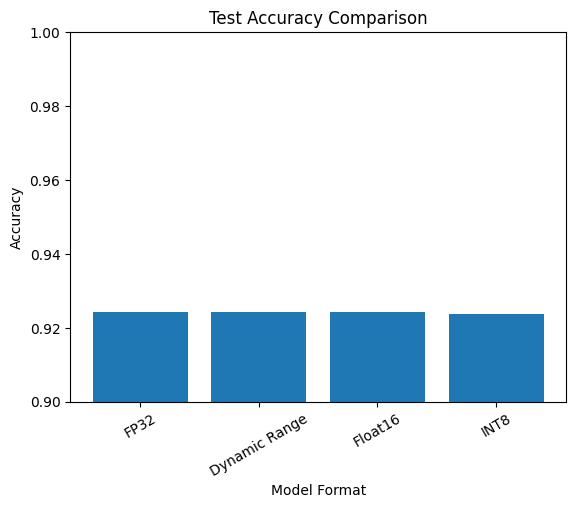

In [22]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#

# Model Size
plt.figure()
plt.bar(df["Format"], df["Model Size (KB)"])
plt.xlabel("Model Format")
plt.ylabel("Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=30)
plt.show()

# Test Accuracy
plt.figure()
plt.bar(df["Format"], df["Test Accuracy"])
plt.xlabel("Model Format")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylim(0.90, 1.00)
plt.show()

#chat again helped with formatting cuz im lazy

### Confusion Matrix for the PTQ Int8 Model


INT8 Test Accuracy: 0.9236511706820495

Classification Report (INT8):
                    precision    recall  f1-score   support

           WALKING       0.90      0.99      0.94       496
  WALKING_UPSTAIRS       0.88      0.93      0.91       471
WALKING_DOWNSTAIRS       0.99      0.82      0.90       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



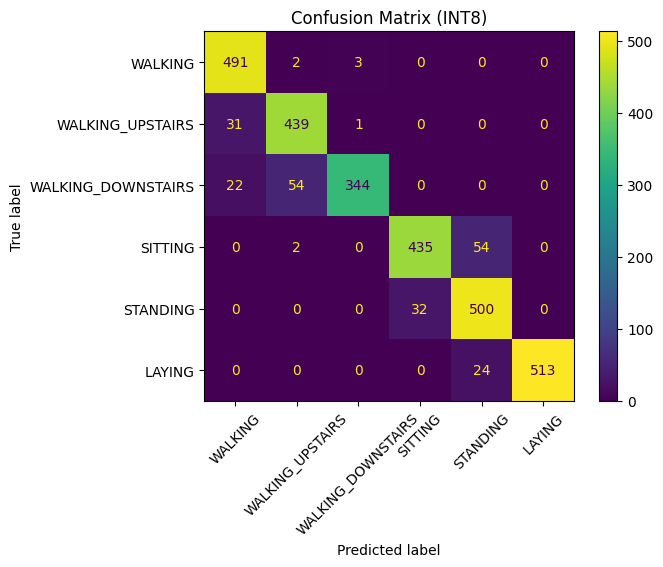

In [23]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

acc_int8, y_pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)
print("INT8 Test Accuracy:", acc_int8)

# Classification report
print("\nClassification Report (INT8):")
print(classification_report(y_test, y_pred_int8, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix (INT8)")
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [24]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Fine-Tune the QAT Model


In [25]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
88/92 [===========================>..] - ETA: 0s - loss: 0.0502 - accuracy: 0.9840WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x7a07845a4fe0> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
92/92 [==============================] - 2s 9ms/step - loss: 0.0494 - accuracy: 0.9845 - val_loss: 0.1247 - val_accuracy: 0.9456
Epoch 2/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0393 - accuracy: 0.9864 - val_loss: 0.1268 - val_accuracy: 0.9463
Epoch 3/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0385 - accuracy: 0.9871 - val_loss: 0.1364 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0351 - accuracy: 0.9879 - val_loss: 0.1259 - val_accuracy: 0.9463
Epoch 5/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0339 - accuracy: 0.9891 - val_loss: 0.

### Evaluate the QAT Keras Model


In [26]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
# Predictionsssssss
y_probs_qat = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_probs_qat, axis=1)

# Accuracy
acc_qat = accuracy_score(y_test, y_pred_qat)
print("QAT Test Accuracy:", acc_qat)

# Classification report
print("\nClassification Report (QAT):")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
93/93 [==============================] - 0s 2ms/step
QAT Test Accuracy: 0.9358669833729216

Classification Report (QAT):
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.96      0.90      0.93       471
WALKING_DOWNSTAIRS       0.96      0.95      0.95       420
           SITTING       0.96      0.85      0.90       491
          STANDING       0.84      0.97      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94     

### Convert the QAT Model to Int8 TensorFlow Lite


In [27]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
tflite_qat_int8 = convert_to_tflite_int8(qat_model)
size_qat_int8 = save_binary_model(tflite_qat_int8, "model_qat_int8.tflite")

acc_qat_int8, y_pred_qat_int8 = evaluate_tflite_model(
    tflite_qat_int8, X_test, y_test
)

print("QAT INT8 Model Size (kB): ", size_qat_int8)
print("QAT INT8 Test Accuracy: ", acc_qat_int8)

INFO:tensorflow:Assets written to: /tmp/tmp4h4zww36/assets


INFO:tensorflow:Assets written to: /tmp/tmp4h4zww36/assets


QAT INT8 Model Size (kB):  185.6953125
QAT INT8 Test Accuracy:  0.9358669833729216


/home/thomas/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  input_array.mean_value, input_array.std_value = quantized_input_stats[
2026-04-23 21:46:52.458442: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:46:52.458518: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:46:52.458757: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp4h4zww36
2026-04-23 21:46:52.460834: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:46:52.460853: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp4h4zww36
2026-04-23 21:46:52.468654: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-

## 12. PTQ Int8 vs QAT Int8


In [28]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
df_int8 = pd.DataFrame([
    {
        "Model": "PTQ INT8",
        "Test Accuracy": acc_int8,
        "Model Size (KB)": size_int8
    },
    {
        "Model": "QAT INT8",
        "Test Accuracy": acc_qat_int8,
        "Model Size (KB)": size_qat_int8
    }
])

df_int8

,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.923651,185.335938
1,QAT INT8,0.935867,185.695312


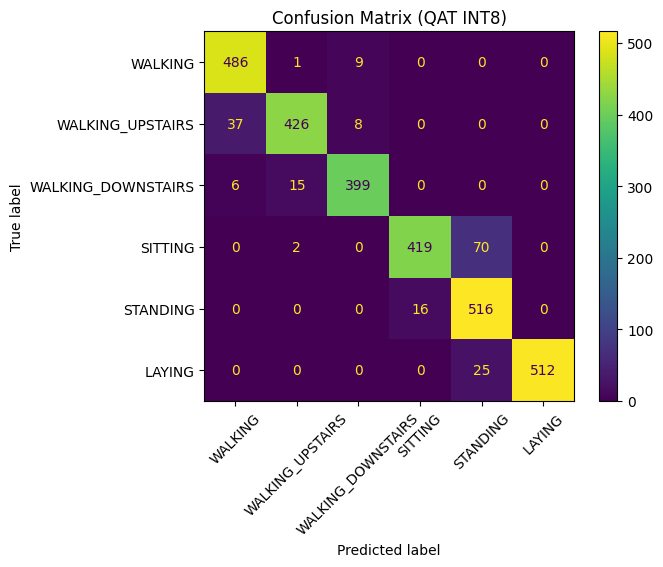

In [29]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat_int8 = confusion_matrix(y_test, y_pred_qat_int8)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_qat_int8,
    display_labels=class_names
)

disp.plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix (QAT INT8)")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
PTQ INT8 (and also the QAT version) dynamic range was very close though.

2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
All but INT8.

4. Did QAT improve the final int8 model compared with PTQ int8?
yes by 1.22 %.

5. Why is this dataset a good fit for a DNN-based TinyML workflow?
Small input size and not a crazy data type like an image or audio file. Also there was only 6 classes and the model was already pretty small before quantization.

6. If you were deploying this model on a resource-constrained device, which version would you choose and why?
QAT INT8 model because its the smallest and has the best accuracy, even higher than the others which is a little strange... I think integers are also better for edge devices anyway.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
